<a href="https://colab.research.google.com/github/mohamed0barhoomi/checkpoint_data/blob/main/projet_final_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50,EfficientNetB0
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import os

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/kermany2018")

print("Path to dataset files:", path)

100%|██████████| 10.8G/10.8G [10:49<00:00, 17.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2


In [3]:
print(os.listdir(path))

['OCT2017 ', 'oct2017']


In [4]:
data=os.path.join(path, 'OCT2017 ')
print(os.listdir(data))

['test', 'train', 'val']


In [5]:
modification=ImageDataGenerator(
    #  preprocessing_function=preprocess_input,
    rescale=1/255.0,
    # validation_split=0.2,
    # rotation_range=20,
    # zoom_range=0.2,
    # width_shift_range=0.3,
    # height_shift_range=0.15,
    #  horizontal_flip=True
    )

In [6]:

train=modification.flow_from_directory(
    os.path.join(data,'train'),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical",
    # subset="training"

)
val=modification.flow_from_directory(
    os.path.join(data,'val'),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical",
    # subset="validation"
)

Found 83484 images belonging to 4 classes.
Found 32 images belonging to 4 classes.


In [7]:
print(train.samples)
print(val.samples)
x, y = next(train)
print(x.shape, y.shape)
x, y = next(val)
print(x.shape, y.shape)

83484
32
(32, 224, 224, 3) (32, 4)
(32, 224, 224, 3) (32, 4)


In [8]:
test=ImageDataGenerator(rescale=1/255.0).flow_from_directory(
    os.path.join(data,"test"),
    batch_size=32,
    target_size=(224,224),
    class_mode="categorical"
)

Found 968 images belonging to 4 classes.


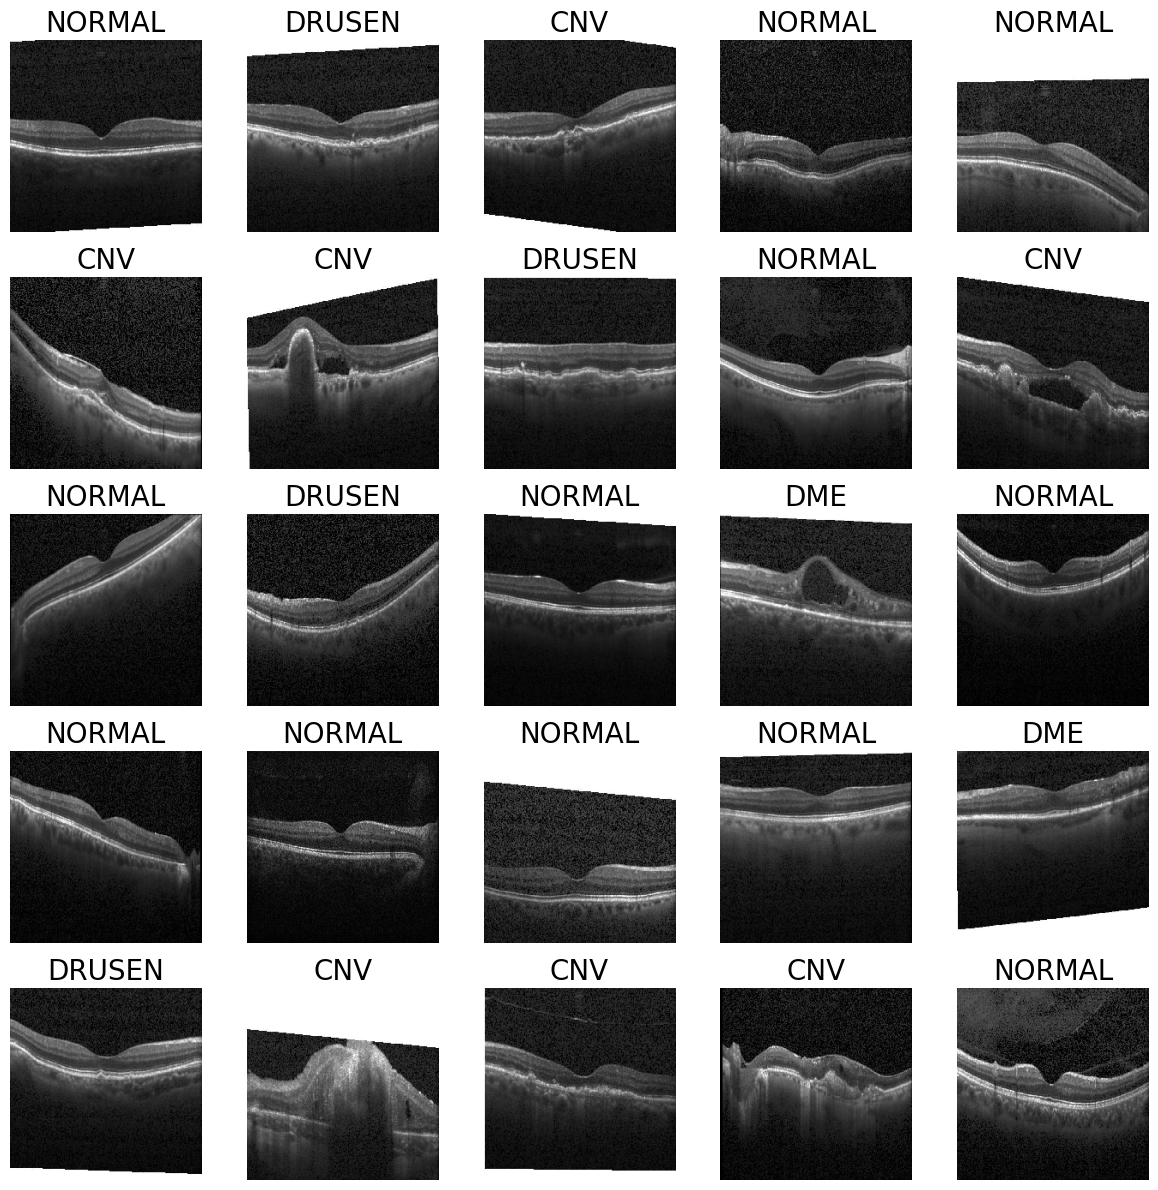

In [9]:
images, labels = next(train)

plt.figure(figsize=(12,12))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    class_index = labels[i].argmax()
    class_name = list(train.class_indices.keys())[class_index]
    plt.title(class_name, fontsize=20)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
base_model=ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [11]:
# for lay in base_model.layers:
#   lay.trainable=False

In [12]:
model=models.Sequential(
  [  base_model,
    layers.Flatten(),
    layers.BatchNormalization(),
    layers.Dense(256,activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(4,activation="softmax")]

)

In [13]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history=model.fit(train,epochs=13,validation_data=val)

Epoch 1/13
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 912s 324ms/step - accuracy: 0.7850 - loss: 1.2682 - val_accuracy: 0.5938 - val_loss: 1.2300
Epoch 2/13
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 809s 310ms/step - accuracy: 0.8131 - loss: 0.5606 - val_accuracy: 0.9062 - val_loss: 0.2026
Epoch 3/13
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 811s 311ms/step - accuracy: 0.8951 - loss: 0.3312 - val_accuracy: 0.7188 - val_loss: 2.9088
Epoch 4/13
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 810s 311ms/step - accuracy: 0.9129 - loss: 0.2804 - val_accuracy: 0.3750 - val_loss: 2.4195
Epoch 5/13
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 809s 310ms/step - accuracy: 0.9141 - loss: 0.2760 - val_accuracy: 0.9688 - val_loss: 0.0737
Epoch 6/13
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 807s 309ms/step - accuracy: 0.9260 - loss: 0.2368 - val_accuracy: 0.9688 - val_loss: 0.1189
Epoch 7/13
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 808s 310ms/step - accuracy: 0.9282 - loss: 0.2341 - val_accuracy: 0.9688 - val_loss: 0.0834
Epoch 8/13
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 808s 310ms/step - ac

In [15]:
acc,loss=model.evaluate(val)
print("first acc : ",acc)
print("first loss : ",loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 1.0000 - loss: 0.0250
first acc :  0.024950766935944557
first loss :  1.0


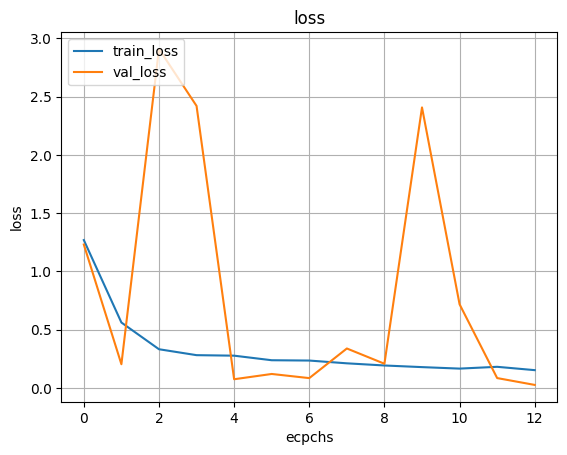

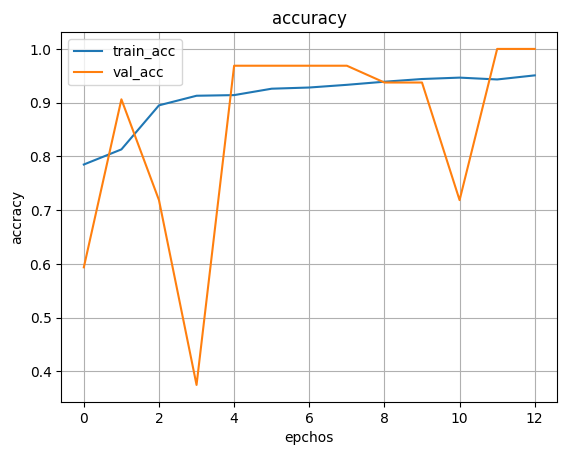

In [16]:
plt.figure()
plt.plot(history.history["loss"],label="train_loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.legend(loc='upper left')
plt.title("loss")
plt.xlabel("ecpchs")
plt.ylabel("loss")
plt.grid()
plt.show()
plt.figure()
plt.plot(history.history["accuracy"],label="train_acc")
plt.plot(history.history["val_accuracy"],label="val_acc")
plt.legend(loc="upper left")
plt.title("accuracy")
plt.xlabel("epchos")
plt.ylabel("accracy")
plt.grid()
plt.show()

In [17]:
# for lay in model.layers:
#   lay.trainable=True

In [18]:
# model.compile(
#     optimizer="Adam",
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

In [19]:
# history_2=model.fit(train,epochs=5,validation_data=val)

In [20]:
# acc2,loss2 =model.evaluate(val)
# print("second acc : ",acc)
# print("second loss : ",loss)

In [21]:
# plt.figure()
# plt.plot(history_2.history["loss"],label="train_loss")
# plt.plot(history_2.history["val_loss"],label="val_loss")
# plt.legend(loc='upper left')
# plt.title("loss")
# plt.xlabel("ecpchs")
# plt.ylabel("loss")
# plt.grid()
# plt.show()
# plt.figure()
# plt.plot(history_2.history["accuracy"],label="train_acc")
# plt.plot(history_2.history["val_accuracy"],label="val_acc")
# plt.legend(loc="upper left")
# plt.title("accuracy")
# plt.xlabel("epchos")
# plt.ylabel("accracy")
# plt.grid()
# plt.show()

In [22]:
test.reset()
pred=model.predict(test)
pred=np.argmax(pred,axis=1)
print(pred)

31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 350ms/step
[2 2 2 3 0 3 0 3 2 3 0 1 1 0 0 3 0 0 1 0 2 0 2 1 2 1 3 0 0 1 3 3 3 1 3 2 2
 3 1 1 2 0 2 0 2 0 3 1 2 1 2 0 0 3 3 3 2 2 3 0 0 2 3 1 3 0 0 3 2 0 2 1 2 0
 0 0 2 3 2 1 1 0 1 3 3 2 2 3 1 2 0 3 1 1 3 2 1 0 1 3 3 1 0 1 1 2 3 2 1 2 0
 3 2 2 1 2 3 0 1 2 0 2 1 2 0 2 3 3 0 1 3 0 1 0 0 0 2 0 1 3 0 3 3 3 0 3 3 0
 2 0 0 1 0 1 2 1 1 3 2 3 3 1 3 1 1 1 0 2 2 1 3 1 3 0 3 0 3 2 1 2 1 1 3 2 1
 1 1 1 3 3 0 3 3 0 2 2 1 2 2 2 3 2 3 2 1 2 1 3 1 3 0 0 3 2 3 3 3 1 0 0 3 3
 0 2 3 1 0 3 3 2 1 2 1 1 2 0 3 3 0 0 1 3 2 1 0 3 1 2 0 3 0 0 2 1 1 2 1 2 1
 1 0 2 1 1 1 2 0 0 1 3 3 2 0 1 0 1 3 2 2 1 3 3 3 1 0 2 3 0 1 1 0 2 0 2 1 0
 0 3 1 3 1 3 2 0 2 2 0 3 2 3 3 3 2 3 3 0 0 1 0 2 0 0 0 1 2 3 3 0 3 3 3 3 1
 2 0 1 0 3 1 2 2 1 0 3 3 2 2 0 2 3 0 0 2 2 3 0 3 2 1 2 1 0 1 0 3 3 0 3 3 0
 1 0 2 2 0 1 2 0 0 1 0 2 3 3 2 3 3 0 3 2 3 1 2 0 0 3 2 0 3 0 2 3 3 0 3 2 1
 0 0 1 2 0 0 1 2 2 2 1 1 0 1 2 0 1 2 2 1 2 0 0 3 1 3 3 2 2 0 0 1 2 2 3 1 1
 0 2 2 0 3 3 0 3 0 3 3 3 3 2 0 3 0 2 1 0 2 2 1 2 1 2 1 3 2

In [23]:
images, labels = next(test)
class_names = list(test.class_indices.keys())
print(labels)

[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]


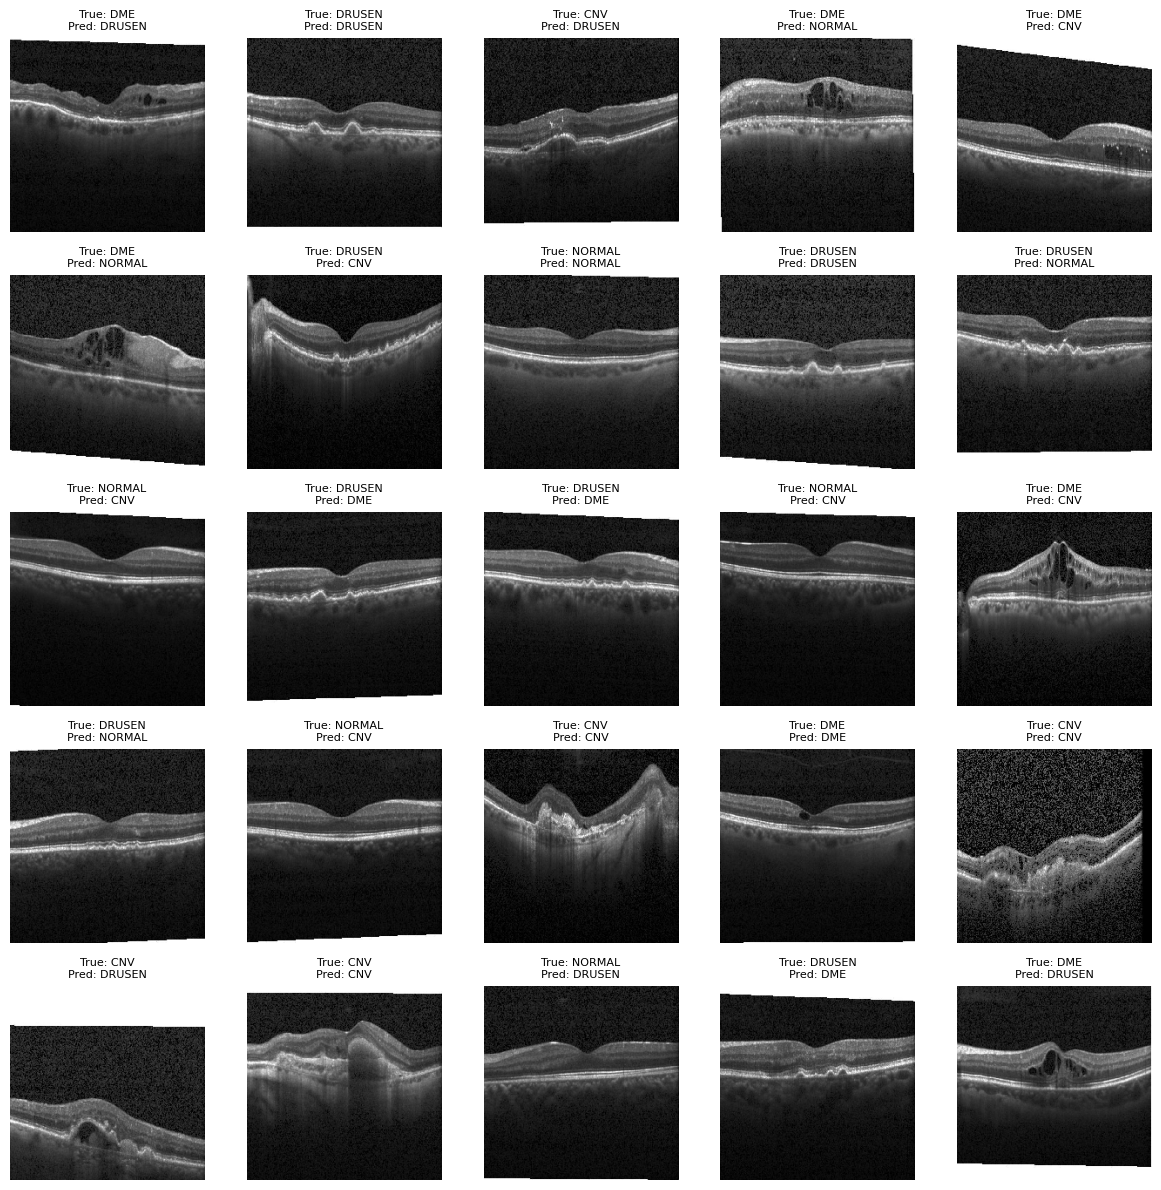

In [24]:


plt.figure(figsize=(12,12))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    true_index = labels[i].argmax()
    pred_index = pred[i]
    plt.title(
        f"True: {class_names[true_index]}\nPred: {class_names[pred_index]}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# from sklearn.metrics import classification_report
# print(classification_report(train,test))

In [26]:
import pickle
with open ("last_model_ayes.plk","wb") as model_file:
  pickle.dump(model,model_file)